### Mashiur Rahman

## Assignment 15: Loan Default Prediction

# Loan Default Prediction

This project uses a Random Forest model to predict whether a customer will default on a loan. It includes data cleaning, visualization, feature engineering, model evaluation, explainability, fairness, and ethical considerations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

## 1. Data Loading and Cleaning

Rows with a missing target value are removed because an unknown loan outcome cannot be used for model training. Duplicate records are also removed.

In [4]:
df = pd.read_csv("bank-loan.csv")

print("Original shape:", df.shape)
display(df.head())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove missing targets and duplicates
df = df.dropna(subset=["default"]).drop_duplicates()
df["default"] = df["default"].astype(int)

print("\nCleaned shape:", df.shape)
display(df.describe())

Original shape: (850, 9)


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0



Missing values:
age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64

Cleaned shape: (700, 9)


,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,34.860000,1.722857,8.388571,8.278571,45.601429,10.260571,1.553553,3.058209,0.261429
std,7.997342,0.928206,6.658039,6.824877,36.814226,6.827234,2.117197,3.287555,0.439727
min,20.000000,1.000000,0.000000,0.000000,14.000000,0.400000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.000000,0.369059,1.044178,0.000000
50%,34.000000,1.000000,7.000000,7.000000,34.000000,8.600000,0.854869,1.987567,0.000000
75%,40.000000,2.000000,12.000000,12.000000,55.000000,14.125000,1.901955,3.923065,1.000000
max,56.000000,5.000000,31.000000,34.000000,446.000000,41.300000,20.561310,27.033600,1.000000


## Basic Visualizations

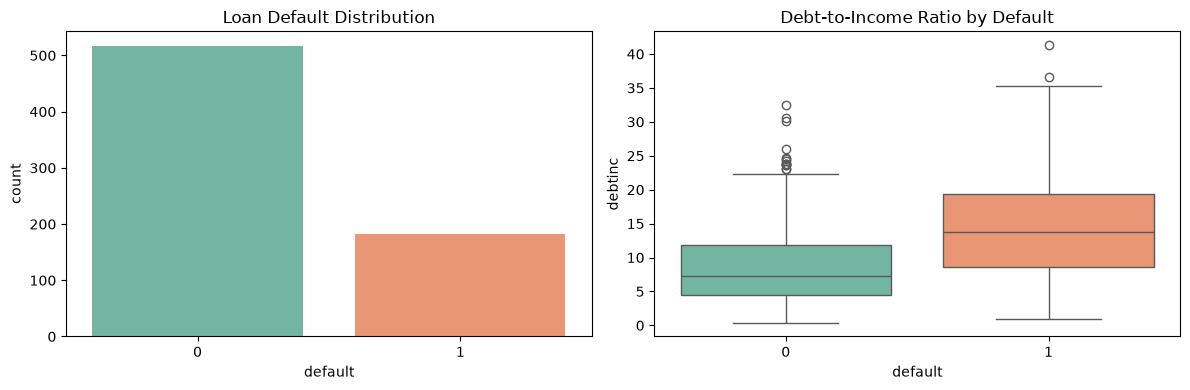

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(
    data=df,
    x="default",
    hue="default",
    palette="Set2",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Loan Default Distribution")

sns.boxplot(
    data=df,
    x="default",
    y="debtinc",
    hue="default",
    palette="Set2",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Debt-to-Income Ratio by Default")

plt.tight_layout()
plt.show()

## Correlation Heatmap

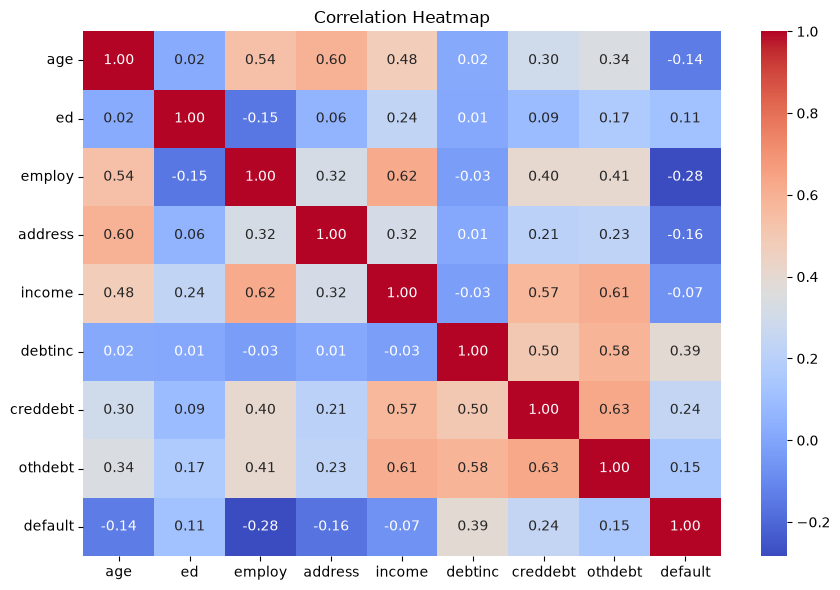

In [6]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 2. Feature Engineering


Two new features are created:

- `total_debt` combines credit debt and other debt.
- `employment_ratio` compares employment years with age.

These features provide information about the customer's total debt and employment stability.

## Feature Engineering and Scaling

In [7]:
# Create new features
df["total_debt"] = df["creddebt"] + df["othdebt"]
df["employment_ratio"] = df["employ"] / df["age"]

# Separate features and target
X = df.drop(columns=["default"])
y = df["default"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 560
Testing records: 140


## Random Forest Model

Random Forest is used because it can identify complex relationships between customer characteristics and loan default. Class balancing is applied because default cases are less common.

## Train and Evaluate Model

In [8]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.757

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.82       103
           1       0.53      0.73      0.61        37

    accuracy                           0.76       140
   macro avg       0.71      0.75      0.72       140
weighted avg       0.79      0.76      0.77       140



## Confusion Matrix

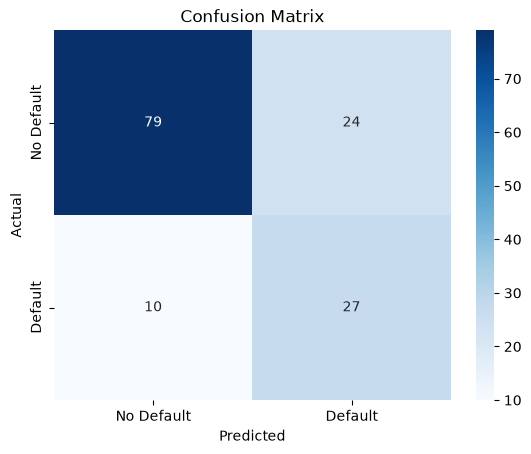

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Feature Importance

,Feature,Importance
9,employment_ratio,0.165577
5,debtinc,0.147293
6,creddebt,0.131715
8,total_debt,0.102437
2,employ,0.102236
7,othdebt,0.089688
0,age,0.080273
3,address,0.078129
4,income,0.077847
1,ed,0.024805


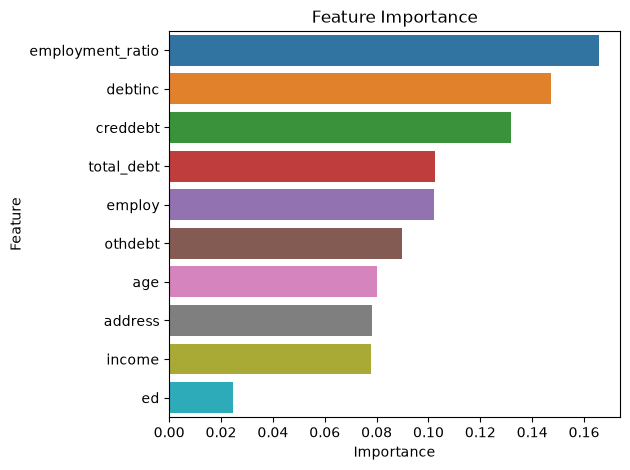

In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance)

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    legend=False
)

plt.title("Feature Importance")
plt.tight_layout()
plt.show()

### Model Findings

The model predicts most loan outcomes correctly. Debt-to-income ratio, employment history, credit debt, total debt, income, and age are important predictors.

Recall for the default class is important because a false negative means the institution failed to identify a customer who actually defaulted.

## 4. SHAP Explainability

SHAP explains how each feature affects model predictions. Positive SHAP values move a prediction toward default, while negative values move it toward no default.

## SHAP Analysis

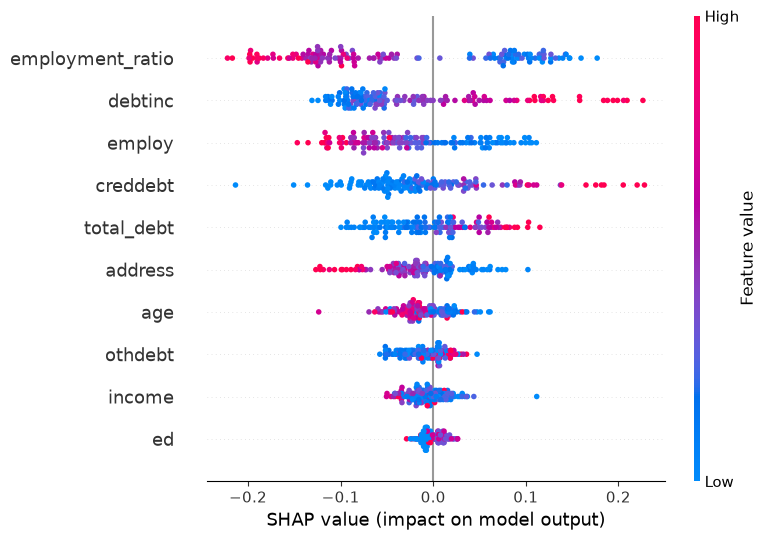

In [11]:
explainer = shap.TreeExplainer(model)
shap_output = explainer.shap_values(X_test_scaled)

# Select SHAP values for the default class
if isinstance(shap_output, list):
    shap_values = shap_output[1]
elif np.array(shap_output).ndim == 3:
    shap_values = np.array(shap_output)[:, :, 1]
else:
    shap_values = shap_output

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

##  Fairness Analysis
The dataset does not contain gender or race. Therefore, age groups are used for a limited fairness comparison. Age is used only to audit model performance and should not be the sole basis for a lending decision.

## Fairness by Age Group

In [12]:
fairness = X_test[["age"]].copy()
fairness["Actual"] = y_test
fairness["Predicted"] = y_pred

fairness["Age Group"] = pd.cut(
    fairness["age"],
    bins=[0, 29, 44, np.inf],
    labels=["Under 30", "30–44", "45+"]
)

fairness_results = fairness.groupby(
    "Age Group",
    observed=False
).apply(
    lambda group: pd.Series({
        "Customers": len(group),
        "Accuracy": accuracy_score(
            group["Actual"],
            group["Predicted"]
        ),
        "Predicted Default Rate": group["Predicted"].mean()
    }),
    include_groups=False
)

display(fairness_results.round(3))

,Customers,Accuracy,Predicted Default Rate
Age Group,,,
Under 30,40.0,0.750,0.400
30–44,83.0,0.735,0.325
45+,17.0,0.882,0.471


## airness and Recommendations

### Fairness Findings and Recommendations

Model performance may differ across age groups. However, some groups contain only a small number of customers, so the results should be interpreted carefully.

The institution should:

- Test the model using a larger and more representative dataset.
- Compare error rates across demographic groups.
- Use human review for borderline decisions.
- Monitor the model regularly.
- Avoid using age as the only reason for rejecting a loan.

## Ethical Considerations


### Fairness

The model should not discriminate based on age, gender, race, disability, or another protected characteristic. Regular fairness testing is necessary.

### Privacy

Income, debt, and default information are sensitive. Data should be encrypted, anonymized, and accessed only by authorized employees.

### Transparency

Customers should receive understandable reasons for important lending decisions. SHAP helps explain which variables influenced a prediction.

### Human Oversight

The model should support employees rather than make final decisions automatically. Customers should be able to request a review or correct inaccurate information.

### Limitations

The dataset is small and does not contain important demographic variables such as gender. The model should be tested using larger and more recent data before real-world use.

## Conclusion


The Random Forest model was used to predict loan default. Debt, income, employment, and customer stability were important predictors.

The model can support loan-risk assessment, but it should be combined with human review, privacy protection, fairness monitoring, and clear explanations.